<a href="https://colab.research.google.com/github/JoakoFuenzalida/Tarea1_OII432-2s-2026-GRUPO-6/blob/main/Tarea1_OII432_2s_2026_GRUPO_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width: 100%; border: none; background: #f8f9fa; padding: 20px; border-radius: 10px;">
    <tr>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://www.inf.ucv.cl/wp-content/uploads/2020/05/logo_escuela.jpg" width="170">
        </td>
        <td style="width: 56%; border: none; vertical-align: middle; text-align: center; padding: 0 20px;">
            <h1 style="font-size: 28px; color: #1a3b5c; margin-bottom: 16px; border-bottom: 2px solid #1a3b5c; padding-bottom: 8px;">Tarea 1: Fundamentos Estadisticos y Prediccion de Demanda</h1>
            <p style="font-size: 16px; margin: 8px 0;"><strong>Pontificia Universidad Catolica de Valparaiso</strong><br>
            <strong>Escuela de Ingenieria Informatica</strong></p>
            <p style="font-size: 14px; color: #333; margin: 12px 0;"><strong>OII432 Machine Learning</strong><br>
            <strong>Semestre: 2-2026</strong><br>
            <strong>Profesor: Carlos Valle</strong></p>
        </td>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/c/cb/PUCV_Escudo2016.svg" width="110">
        </td>
    </tr>
</table>

### Integrantes:
* Joaquín Fuenzalida
* Joaquín Castro
* BenjamÍn Rodriguez
* Ignacion Ávila

# Tarea 1: Fundamentos Estadísticos y Predicción de Demanda

Objetivo: Medir sobre datos reales los conceptos del capitulo, riesgo empírico, condicionamiento, sesgo, varianza y regularización, y luego aplicarlos a un problema abierto de predicción de demanda.

Temas: minimizacion del riesgo empírico, ecuaciones normales, gradiente descendente, de la verosimilitud a la perdida, sesgo y varianza sobre remuestreos, Ridge y Lasso, lectura MAP, validación y feature engineering.

Formalidades

* Los códigos de referencia son solo orientativos.
* Entregar un Jupyter Notebook (.ipynb) con código, análisis e interpretaciones en celdas markdown.
* Trabajo en grupos de 3 o 4. La copia parcial o total será penalizada con nota 1.
* Entregable subido a un repositorio privado de GitHub. Enviar el link a <carlos.valle@pucv.cl> (Asunto: [OII432-2-2026 Tarea1]) e invitar como colaborador al usuario **cvalle231**.
* Cierre del desafío Kaggle: **jueves 11 de septiembre, 10:59 horas**.
* Fecha de entrega: **lunes 14 de septiembre, 13:30 horas**.
* Deben estar preparados para presentar su tarea en la fecha indicada.

La tarea tiene dos partes de igual ponderación: la pregunta dirigida (50%) y el desafío Kaggle (50%).

# Pregunta 1: (50%) Predicción de la fuerza compresiva del concreto

Los mínimos cuadrados son el modelo más simple del curso, y por eso mismo el único donde casi todo se puede calcular a mano: hay solución cerrada, el costo es convexo, y el estimador tiene media y covarianza conocidas. Esa transparencia permite usarlo como laboratorio.

Trabajaremos con Concrete Compressive Strength: 1.030 mezclas de hormigón, ocho ingredientes y la resistencia a la compresión resultante en megapascales.

El dataset tiene dos propiedades útiles para lo que queremos mostrar. Sus columnas son proporciones de una mezcla, así que vienen correlacionadas por construcción. Y la variable que la ciencia del hormigón considera determinante de la resistencia, la razón agua/cemento, no está en la tabla: hay que construirla.

Esta parte se evalúa sobre 85 puntos, repartidos entre las subpreguntas según el trabajo que exige cada una. La nota se obtiene como:

$$\text{Nota Pregunta 1} = \frac{\text{puntos obtenidos}}{85} \times 6 + 1.$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette("deep")
np.random.seed(42)

# Parte 1: Datos y protocolo experimental

## 1. Carga y exploración

### 1a) (2 pts) Carga el dataset Concrete Compressive Strength desde UCI

Deja los atributos en `X` y la resistencia en `y`, ambos como DataFrame/Series de pandas.

In [ ]:
import pandas as pd
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=165)

# TODO: extraer atributos y target
X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
print(f"Mezclas: {df.shape[0]} | Atributos: {X.shape[1]}")
df.head()

Mezclas: 1030 | Atributos: 8


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

Cargamos el dataset *Concrete Compressive Strength* directo desde el repositorio UCI (id=165) con `ucimlrepo`, separando atributos (`X`) y resistencia (`y`). Es el punto de partida: sin esto no hay nada que modelar.

</div>


### 1b) (2 pts) Describe la distribución de cada atributo y la matriz de correlaciones

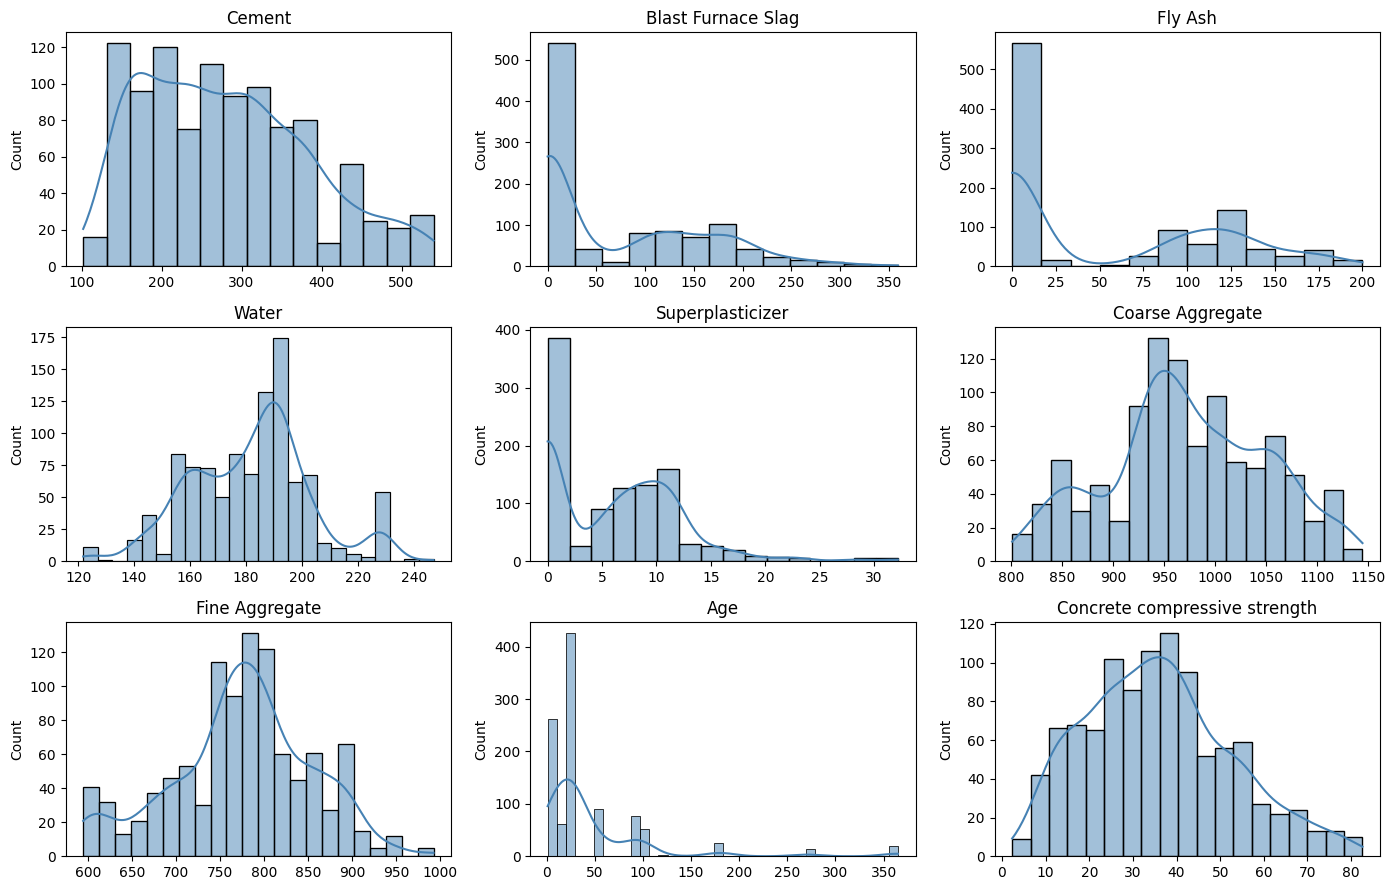

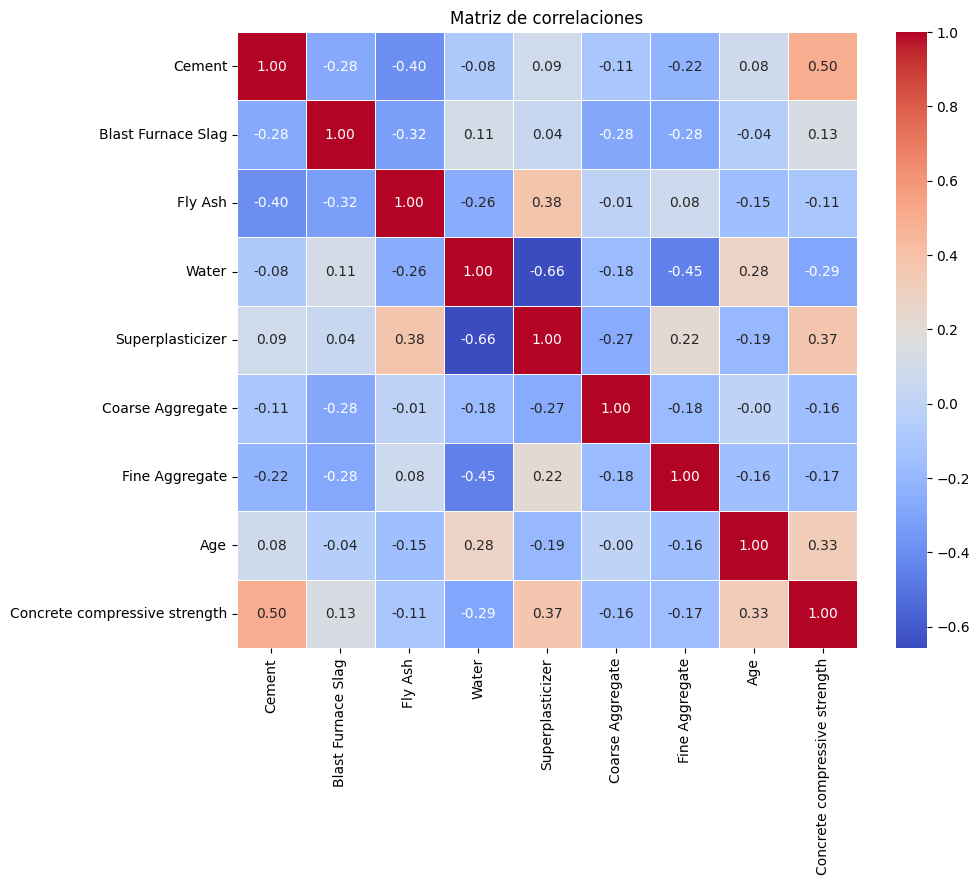

                                count        mean         std     min  \
Cement                         1030.0  281.167864  104.506364  102.00   
Blast Furnace Slag             1030.0   73.895825   86.279342    0.00   
Fly Ash                        1030.0   54.188350   63.997004    0.00   
Water                          1030.0  181.567282   21.354219  121.80   
Superplasticizer               1030.0    6.204660    5.973841    0.00   
Coarse Aggregate               1030.0  972.918932   77.753954  801.00   
Fine Aggregate                 1030.0  773.580485   80.175980  594.00   
Age                            1030.0   45.662136   63.169912    1.00   
Concrete compressive strength  1030.0   35.817961   16.705742    2.33   

                                   25%      50%       75%     max  
Cement                         192.375  272.900   350.000   540.0  
Blast Furnace Slag               0.000   22.000   142.950   359.4  
Fly Ash                          0.000    0.000   118.300   200.1

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.ravel(), df.columns):
    # TODO: histograma de cada columna
    sns.histplot(df[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel("")
    pass
plt.tight_layout()
plt.show()

# TODO: matriz de correlaciones como heatmap
plt.figure(figsize=(10, 8))
correlaciones = df.corr()
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlaciones")
plt.show()
print(df.describe().T)

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (1b):** Graficamos histogramas por atributo y la matriz de correlación. El objetivo es detectar asimetrías, outliers y relaciones lineales fuertes antes de ajustar cualquier modelo.

</div>


### 1c) (1 pt) Los atributos son proporciones de una mezcla. ¿Qué pares aparecen más correlacionados y por qué tiene sentido físico?

Respuesta 1c): Los atributos al ser proporciones de una mezcla, es lógico que dominen las correlaciones negativas: si aumentas un ingrediente, obligatoriamente reduces otro para mantener el 100% de la mezcla, los pares mas correlacionados son:
- Water y Superplasticizer -0.66: Es la correlacion inversa más fuerte. Tiene sentidor fisico proq ue el Superplasticizer o superplastificante es un aditivo que sirve para darle fluidez al hormigón sin tener que agregarle mas agua.
- Water y Fine Aggregate -0.45: Su relación inversa es fuerte por el tema del desplazamiento voluméntrico. Los arido como la arena son el relleno principal de la mezcla.
- Cemenet y fly ash -0.40: Su relación es funcional. Se explica porque la ceniza volante se usa mucho como sustituto del cemento para abaratar la mezcla. Como los dos hacen el mismo trabajo de pegamento, si subes uno, bajas el otro.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (1c):** Como los atributos son proporciones de una mezcla, es esperable que dominen correlaciones negativas: si sube un ingrediente, otro baja para mantener el 100%. Por eso Water–Superplasticizer, Water–Fine Aggregate y Cement–Fly Ash aparecen como los pares más correlacionados, y cada uno tiene una explicación física (fluidez, desplazamiento volumétrico, sustitución del cemento).

</div>


### 1d) (2 pts) Particiona en entrenamiento, validación y prueba, y estandariza correctamente

El scaler debe ajustarse solo con los datos de entrenamiento.

In [ ]:
# PARTICION: Train ajusta modelos, validacion compara decisiones y test se reserva para la evaluacion final.
X_tr, X_temp, y_tr, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr)

# 2. Transformar validación y test usando la media y desviación de train (NUNCA hacer fit aquí)
X_val_s = scaler.transform(X_val)
X_te_s = scaler.transform(X_te)

print(f"Train {len(X_tr)} | Val {len(X_val)} | Test {len(X_te)}")

Train 618 | Val 206 | Test 206


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (1d):** Hacemos el split 60/20/20 (train/val/test) y ajustamos el `StandardScaler` **solo con train**. Este es el punto de higiene metodológica más importante de toda la tarea: el scaler nunca debe "ver" datos de validación o prueba, o se filtra información.

</div>


### 1e) (2 pts) Repite el escalado de forma incorrecta, ajustando el scaler con la tabla completa, y compara el error de prueba de ambas versiones

In [ ]:
# PARTICION: Train ajusta modelos, validacion compara decisiones y test se reserva para la evaluacion final.
# LEAKAGE: Aqui se muestra a proposito el error de ajustar el scaler con todo X, incluyendo test. Sirve solo para compararlo con el protocolo correcto.

# TODO: escalar mal (fit sobre X completo) y volver a ajustar el modelo
scaler_mal = StandardScaler()
X_mal_s = scaler_mal.fit_transform(X)

X_tr_m, X_temp_m, y_tr_m, y_temp_m = train_test_split(X_mal_s, y, test_size=0.4, random_state=42)
X_val_m, X_te_m, y_val_m, y_te_m = train_test_split(X_temp_m, y_temp_m, test_size=0.5, random_state=42)
# TODO: comparar el error de prueba de la version correcta y la incorrecta
mod_corr = LinearRegression().fit(X_tr_s, y_tr)
rmse_corr = np.sqrt(mean_squared_error(y_te, mod_corr.predict(X_te_s)))
print(f"Escalado correcto: RMSE test = {rmse_corr:.4f}")

mod_incorr = LinearRegression().fit(X_tr_m, y_tr_m)
rmse_incorr = np.sqrt(mean_squared_error(y_te_m, mod_incorr.predict(X_te_m)))
print(f"Escalado incorrecto: RMSE test = {rmse_incorr:.4f}")

Escalado correcto: RMSE test = 11.0024
Escalado incorrecto: RMSE test = 11.0024


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (1e):** Repetimos el escalado de forma incorrecta, ajustando el `StandardScaler` sobre la tabla completa (incluyendo val/test) antes de particionar. Comparamos el RMSE de test de ambas versiones.

</div>


### 1f) (1 pt) Explica qué información se filtró exactamente en la versión incorrecta, y por qué el error resultante deja de ser una estimación honesta del riesgo

Respuesta 1f): Se produce fuga de información porque el escalador incorrecto usa la media y desviación estándar calculadas también con validación y prueba. Sin embargo, en este experimento el RMSE de prueba no cambió: la regresión lineal sin regularización es invariante ante transformaciones lineales invertibles de las variables, siempre que el modelo incluya intercepto. Esto no vuelve correcto el procedimiento; con modelos regularizados, basados en distancia o con otra etapa de preprocesamiento, la fuga puede alterar la evaluación.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (1f):** El resultado es contraintuitivo: el RMSE dio **igual** en ambas versiones. La razón es que la regresión lineal con intercepto es invariante ante transformaciones lineales invertibles de los predictores, así que en este caso particular el leakage no cambia el resultado. Esto **no** vuelve correcto el procedimiento: con Ridge/Lasso o modelos basados en distancia, la fuga de información sí alteraría la evaluación.

</div>


# Parte 2: Mínimos cuadrados y condicionamiento

## 2. Solución exacta

### 2a) (3 pts) Implementa mínimos cuadrados resolviendo las ecuaciones normales, sin usar sklearn

Construye la matriz de diseño con la columna de unos y resuelve el sistema.

In [ ]:
# ECUACIONES NORMALES: Agregamos una columna de unos para el intercepto y resolvemos el sistema sin calcular la inversa explicita.

def minimos_cuadrados(X, y):
    """Retorna beta resolviendo las ecuaciones normales"""
    Xb = np.c_[np.ones(len(X)), X]

    beta = np.linalg.solve(Xb.T @ Xb, Xb.T @ y)
    return beta

beta_propio = minimos_cuadrados(X_tr_s, y_tr.values.ravel())

modelo_sk = LinearRegression().fit(X_tr_s, y_tr)
print("Propio :", np.round(beta_propio, 4))
print("sklearn:", np.round(np.r_[modelo_sk.intercept_, modelo_sk.coef_.ravel()], 4))

Propio : [36.0074 12.7765  9.8731  5.2292 -1.5352  3.163   2.0214  2.7631  7.1389]
sklearn: [36.0074 12.7765  9.8731  5.2292 -1.5352  3.163   2.0214  2.7631  7.1389]


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (2a):** Implementamos mínimos cuadrados a mano resolviendo las ecuaciones normales ($\beta=(X^TX)^{-1}X^Ty$) con `np.linalg.solve` en vez de invertir explícitamente. Los coeficientes coinciden exactamente con los de `sklearn`, lo que valida la implementación.

</div>


### 2b) (1 pt) ¿Por qué conviene resolver el sistema con `np.linalg.solve` en lugar de calcular la inversa con `np.linalg.inv`?

Respuesta 2b): Calcular la matriz inversa explícita $(X^TX)^{-1}$ es computacionalmente costoso ($O(d^3)$) y propenso a inestabilidad numérica por acumulación de errores de punto flotante. np.linalg.solve resuelve el sistema $A\beta = b$ mediante factorización directa (como Cholesky o LU), lo cual es más rápido, usa menos memoria y tiene un orden de error numérico significativamente menor.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (2b):** Usamos `np.linalg.solve` porque calcular la inversa explícita con `np.linalg.inv` es más costoso ($O(d^3)$) y numéricamente inestable. `solve` resuelve el sistema por factorización directa (LU/Cholesky), más rápido y preciso.

</div>


### 2c) (2 pts) Verifica que la solución encontrada es un mínimo y no un punto silla

In [ ]:
# HESSIANA: Sus valores propios indican la curvatura del costo. Si todos son positivos, la solucion es un minimo global.

Xb = np.c_[np.ones(len(X_tr_s)), X_tr_s]
# TODO: calcular la Hessiana y sus valores propios
Hessiana = (2 / len(X_tr_s)) * (Xb.T @ Xb)
valores_propios = np.linalg.eigvalsh(Hessiana)

print("Valores propios:", np.round(valores_propios, 4))
print("Todos positivos:", np.all(valores_propios > 0))

Valores propios: [0.0611 0.3546 1.5467 1.9459 2.     2.0034 2.5975 2.9251 4.5656]
Todos positivos: True


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (2c):** Calculamos la Hessiana del costo y sus valores propios: todos son positivos, lo que confirma que la función es estrictamente convexa y que la solución encontrada es un mínimo global, no un punto silla.

</div>


### 2d) (2 pts) Calcula el número de condición del sistema sobre los datos crudos, centrados y estandarizados

In [ ]:
# CONDICIONAMIENTO: Calculamos cuan sensible es el sistema numericamente. Un numero alto significa que pequenas perturbaciones pueden amplificarse.

def numero_condicion(X):
  Xb = np.c_[np.ones(len(X)), X]
  # Matriz del sistema A = X^T X
  A = Xb.T @ Xb
  return np.linalg.cond(A)

# TODO: evaluar sobre datos crudos, centrados y estandarizados
X_tr_raw = X_tr.values
X_tr_centrado = X_tr.values - X_tr.values.mean(axis=0)

print(f"crudos        : {numero_condicion(X_tr_raw):>16,.1f}")
print(f"centrados     : {numero_condicion(X_tr_centrado):>16,.1f}")
print(f"estandarizados: {numero_condicion(X_tr_s):>16,.1f}")

crudos        : 10,749,601,918.4
centrados     :         13,748.6
estandarizados:             74.7


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (2d):** Calculamos el número de condición sobre datos crudos, centrados y estandarizados. Baja de ~10 mil millones a ~13.700 y luego a ~75. Muestra cómo el escalado mejora drásticamente el condicionamiento numérico del problema.

</div>


### 2e) (2 pts) Verifica que, pese a esa diferencia, las predicciones del modelo son idénticas en los tres casos

In [ ]:
# INVARIANCIA: Ajustamos el mismo modelo en tres escalas. Luego comparamos predicciones para comprobar que cambiar unidades no cambia la funcion lineal representable.

# TODO: ajustar el modelo sobre las tres versiones y comparar las predicciones
b_raw = minimos_cuadrados(X_tr_raw, y_tr.values.ravel())
b_cent = minimos_cuadrados(X_tr_centrado, y_tr.values.ravel())
b_std = minimos_cuadrados(X_tr_s, y_tr.values.ravel())

# Predecir sobre el conjunto de prueba transformado equivalentemente
y_pred_raw = np.c_[np.ones(len(X_te)), X_te.values] @ b_raw
y_pred_cent = np.c_[np.ones(len(X_te)), X_te.values - X_tr.values.mean(axis=0)] @ b_cent
y_pred_std = np.c_[np.ones(len(X_te_s)), X_te_s] @ b_std

dif_max = max(np.max(np.abs(y_pred_raw - y_pred_std)), np.max(np.abs(y_pred_cent - y_pred_std)))
print("Maxima diferencia entre predicciones:", dif_max)

Maxima diferencia entre predicciones: 5.243805389909539e-12


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (2e):** Pese a la enorme diferencia de condicionamiento, las predicciones de los tres modelos (crudo, centrado, estandarizado) son **idénticas**. Son solo reparametrizaciones del mismo espacio de funciones, consistente con lo visto en 1f.

</div>


### 2f) (2 pts) Si el número de condición cambia varios órdenes de magnitud sin que cambie el modelo, ¿qué está midiendo sobre datos crudos? ¿Y sobre datos estandarizados?

Respuesta 2f):

*   Sobre datos crudos: El número de condición ($\kappa$) mide la disparidad de escalas y la falta de centrado respecto al intercepto (la columna de 1s magnifica la correlación espuria con columnas de medias grandes como Coarse Aggregate $\approx 1000$).
*   Sobre datos estandarizados: $\kappa$ elimina el efecto de las unidades y mide la multicolinealidad intrínseca real entre las variables explicativas (la física de la mezcla).
*  Invarianza: Las predicciones finales son idénticas porque la estandarización es una transformación lineal invertible ($X_{std} = (X - \mu)D^{-1}$); el espacio vectorial abarcado por las columnas de la matriz de diseño es exactamente el mismo.  




<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (2f):** Sobre datos crudos, el número de condición mezcla dos efectos: la disparidad de escalas entre variables y la falta de centrado (el intercepto se correlaciona espuriamente con columnas de media alta). Sobre datos estandarizados, aísla la multicolinealidad real entre variables explicativas. En ambos casos las predicciones no cambian.

</div>


## 3. Gradiente descendente

### 3a) (3 pts) Implementa gradiente descendente batch y guarda el historial del costo

In [ ]:
# GRADIENTE DESCENDENTE: En cada iteracion calculamos prediccion, error, gradiente, nueva beta y el costo MSE para observar si converge.

def gradiente_descendente(X, y, alpha=0.01, n_iter=500):
    """Retorna beta y el historial del costo por iteracion."""
    Xb = np.c_[np.ones(len(X)), X]
    N = len(X)  # Cantidad de muestras
    beta = np.zeros(Xb.shape[1])
    historial = []

    for _ in range(n_iter):
        predicciones = Xb @ beta
        errores = predicciones - y
        gradiente = (2 / N) * (Xb.T @ errores)
        beta = beta - alpha * gradiente
        costo = np.mean(errores**2)
        historial.append(costo)

    return beta, historial

beta_gd, hist = gradiente_descendente(X_tr_s, y_tr.values.ravel(), alpha=0.05, n_iter=1000)
print("GD      :", np.round(beta_gd, 4))
print("Exacto  :", np.round(beta_propio, 4))

GD      : [36.0074 12.476   9.5758  4.9752 -1.7726  3.136   1.8043  2.4819  7.1299]
Exacto  : [36.0074 12.7765  9.8731  5.2292 -1.5352  3.163   2.0214  2.7631  7.1389]


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (3a):** Implementamos gradiente descendente batch guardando el historial del costo por iteración, para poder graficar la curva de convergencia después.

</div>


### 3b) (2 pts) Compara la convergencia sobre datos crudos y estandarizados usando la misma tasa de aprendizaje

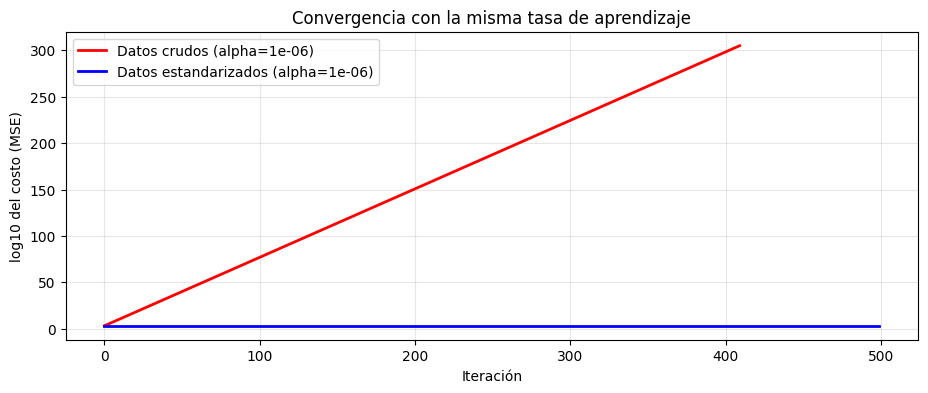

In [ ]:
# COMPARACION JUSTA: Usamos exactamente la misma tasa alpha para datos crudos y estandarizados. El comportamiento distinto viene de la escala de los datos.

hist_raw_finito = np.array(hist_raw)
hist_std_finito = np.array(hist_std)

hist_raw_finito = hist_raw_finito[
    np.isfinite(hist_raw_finito) & (hist_raw_finito > 0)
]

hist_std_finito = hist_std_finito[
    np.isfinite(hist_std_finito) & (hist_std_finito > 0)
]

plt.figure(figsize=(11, 4))

plt.plot(
    np.log10(hist_raw_finito),
    label=f"Datos crudos (alpha={alpha_comun})",
    color="red",
    linewidth=2
)

plt.plot(
    np.log10(hist_std_finito),
    label=f"Datos estandarizados (alpha={alpha_comun})",
    color="blue",
    linewidth=2
)

plt.xlabel("Iteración")
plt.ylabel("log10 del costo (MSE)")
plt.title("Convergencia con la misma tasa de aprendizaje")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (3b):** Con la misma tasa de aprendizaje, comparamos la convergencia sobre datos crudos vs. estandarizados.

</div>


### 3c) (2 pts) Relaciona lo observado con el número de condición de 2d). ¿Existe alguna tasa de aprendizaje que funcione bien sobre los datos crudos?

Respuesta 3c): Al usar la misma tasa de aprendizaje \(\alpha=10^{-6}\), el costo de los datos crudos crece explosivamente y el algoritmo diverge. En cambio, sobre datos estandarizados el costo permanece estable. Esto confirma que la mala escala y el elevado número de condición de los datos crudos vuelven inestable el gradiente descendente.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (3c):** Sobre datos crudos el costo diverge (explota); sobre estandarizados converge de forma estable. Esto se conecta directamente con el mal condicionamiento visto en 2d: un $\kappa$ muy alto implica que casi no existe una tasa de aprendizaje que funcione bien en todas las direcciones del espacio de parámetros a la vez.

</div>


# Parte 3: De la verosimilitud a la función de pérdida

## 4. El caso gaussiano

### 4a) (2 pts) Deriva que maximizar la verosimilitud bajo ruido gaussiano equivale a minimizar el error cuadrático

Escribe el modelo con ruido, la log-verosimilitud de la muestra, e indica qué términos dependen de los parámetros y cuáles no.

Respuesta 4a):

Suponemos el modelo $y_i = x_i^T \beta + \epsilon_i$, con $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$ i.i.d.

1.   La función de densidad de probabilidad para cada muestra es:$$p(y_i \vert{} x_i, \beta, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - x_i^T\beta)^2}{2\sigma^2}\right)$$
2.   La función de verosimilitud conjunta de la muestra es el producto de las probabilidades:$$L(\beta, \sigma^2) = \prod_{i=1}^N \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - x_i^T\beta)^2}{2\sigma^2}\right)$$
3. Aplicando logaritmo natural ($\log L$):$$\ell(\beta, \sigma^2) = -\frac{N}{2}\ln(2\pi) - \frac{N}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^N (y_i - x_i^T\beta)^2$$
4. Los términos $-\frac{N}{2}\ln(2\pi) - \frac{N}{2}\ln(\sigma^2)$ son constantes respecto a $\beta$. Para maximizar $\ell(\beta)$, debemos minimizar el término restante:$$\arg\max_\beta \ell(\beta) = \arg\min_\beta \frac{1}{2\sigma^2} \sum_{i=1}^N (y_i - x_i^T\beta)^2 = \arg\min_\beta \sum_{i=1}^N (y_i - x_i^T\beta)^2$$

Demostrando que el estimador de Máxima Verosimilitud (MLE) es idéntico al de Mínimos Cuadrados (OLS).


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (4a):** Bajo ruido gaussiano i.i.d., derivamos que maximizar la log-verosimilitud equivale exactamente a minimizar la suma de errores cuadráticos: los términos que no dependen de $\beta$ se descartan al optimizar, quedando solo el término de error cuadrático.

</div>


### 4b) (3 pts) Verificalo numéricamente

Evalúa la log-verosimilitud y el error cuadrático sobre una grilla de valores de un coeficiente, dejando los demas fijos en su valor óptimo, y grafica ambas curvas.

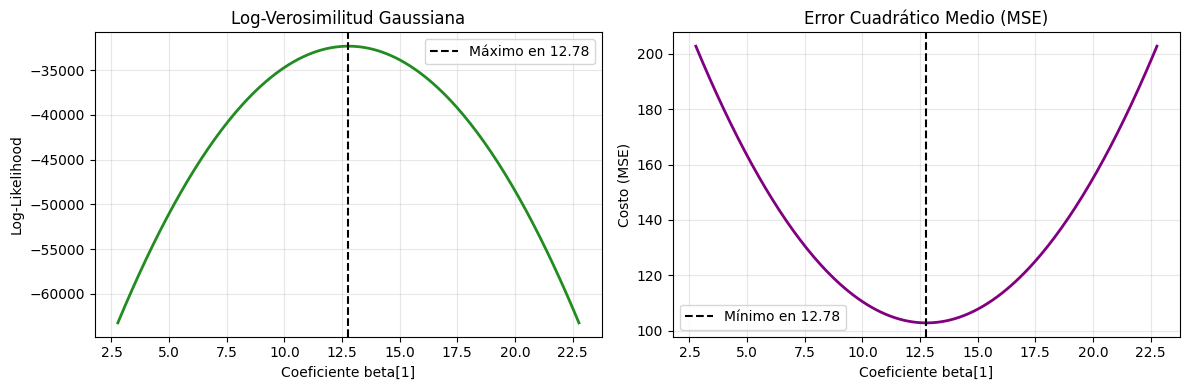

In [ ]:
# VEROSIMILITUD: Esta funcion mide que tan compatibles son los datos con un modelo gaussiano. Al aumentar, el ajuste mejora.

def log_verosimilitud(beta, X, y, sigma2=1.0):
  Xb = np.c_[np.ones(len(X)), X]
  N = len(y)
  residuos = y - Xb @ beta
  return - (N / 2) * np.log(2 * np.pi * sigma2) - (1 / (2 * sigma2)) * np.sum(residuos**2)

j = 1  # coeficiente a barrer (Cement)
grilla = np.linspace(beta_propio[j] - 10, beta_propio[j] + 10, 200)

# Evaluar log-verosimilitud y error cuadrático sobre la grilla
log_liks = []
mses = []
beta_temp = beta_propio.copy()
Xb_tr = np.c_[np.ones(len(X_tr_s)), X_tr_s]
y_real = y_tr.values.ravel()

for val in grilla:
    beta_temp[j] = val
    # Guardamos la log-verosimilitud
    log_liks.append(log_verosimilitud(beta_temp, X_tr_s, y_real, sigma2=1.0))
    # Guardamos el error cuadrático medio (MSE)
    mses.append(np.mean((y_real - Xb_tr @ beta_temp)**2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Log-Verosimilitud
ax[0].plot(grilla, log_liks, color='forestgreen', lw=2)
ax[0].axvline(beta_propio[j], color='black', linestyle='--', label=f"Máximo en {beta_propio[j]:.2f}")
ax[0].set_title("Log-Verosimilitud Gaussiana")
ax[0].set_xlabel(f"Coeficiente beta[{j}]")
ax[0].set_ylabel("Log-Likelihood")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Gráfico 2: Error Cuadrático Medio
ax[1].plot(grilla, mses, color='purple', lw=2)
ax[1].axvline(beta_propio[j], color='black', linestyle='--', label=f"Mínimo en {beta_propio[j]:.2f}")
ax[1].set_title("Error Cuadrático Medio (MSE)")
ax[1].set_xlabel(f"Coeficiente beta[{j}]")
ax[1].set_ylabel("Costo (MSE)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (4b):** Verificamos numéricamente barriendo un coeficiente en una grilla de valores: la curva de log-verosimilitud (invertida) y la de error cuadrático tienen el mismo mínimo.

</div>


### 4c) (1 pt) ¿Qué papel juega la varianza del ruido en esta equivalencia? ¿Cambia el minimizador si cambia sigma cuadrado?

Respuesta 4c): La varianza $\sigma^2$ actúa únicamente como una constante multiplicativa positiva de escala ($1 / 2\sigma^2$). Por ende, no cambia el minimizador $\beta^*$. $\beta^*$ siempre será el mismo sin importar el valor de $\sigma^2$.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (4c):** $\sigma^2$ solo escala la función objetivo por una constante positiva ($1/2\sigma^2$), por lo que no cambia el minimizador $\beta^*$: el óptimo es el mismo sin importar cuánta varianza asumamos en el ruido.

</div>


## 5. Perdidas robustas

### 5a) (2 pts) Contamina los datos de entrenamiento

Multiplica por 3 la resistencia de un 3% de las mezclas, elegidas al azar.

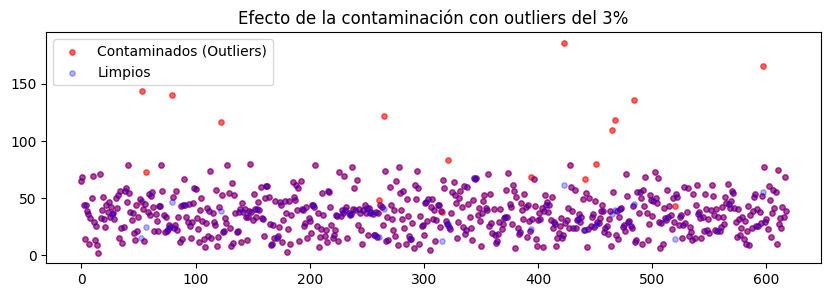

In [ ]:
# OUTLIERS: Contaminamos solo train para simular mediciones extremas y comparar la sensibilidad de MSE frente a MAE.

rng = np.random.default_rng(42)

y_tr_sucio = y_tr.values.ravel().copy()
n_contaminar = int(0.03 * len(y_tr_sucio))
idx_contaminados = rng.choice(len(y_tr_sucio), size=n_contaminar, replace=False)
# TODO: elegir el 3% de indices y multiplicar su valor por 3
y_tr_sucio[idx_contaminados] *= 3

plt.figure(figsize=(10, 3))
# TODO: visualizar el efecto de la contaminacion
plt.scatter(range(len(y_tr_sucio)), y_tr_sucio, label='Contaminados (Outliers)', color='red', alpha=0.6, s=15)
plt.scatter(range(len(y_tr)), y_tr.values.ravel(), label='Limpios', color='blue', alpha=0.3, s=15)
plt.title("Efecto de la contaminación con outliers del 3%")
plt.legend()
plt.show()

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (5a):** Contaminamos el 3% de las etiquetas de entrenamiento, multiplicando su valor por 3, para simular outliers extremos.

</div>


### 5b) (3 pts) Ajusta dos modelos sobre los datos contaminados: uno minimizando error cuadrático y otro minimizando error absoluto

In [ ]:
# OUTLIERS: Contaminamos solo train para simular mediciones extremas y comparar la sensibilidad de MSE frente a MAE.
# COMPARACION DE PERDIDAS: La perdida cuadratica castiga mucho los errores grandes; la absoluta los castiga de forma lineal.

from scipy.optimize import minimize

def perdida(beta, X, y, tipo="cuadratica"):
  Xb = np.c_[np.ones(len(X)), X]
  r = y - np.c_[np.ones(len(X)), X] @ beta
  if tipo == "cuadratica":
    return np.sum(r**2)
  elif tipo == "absoluta":
    return np.sum(np.abs(r))

# TODO: minimizar ambas perdidas sobre los datos contaminados
b_init = np.zeros(X_tr_s.shape[1] + 1)
res_l2 = minimize(perdida, b_init, args=(X_tr_s, y_tr_sucio, "cuadratica"))
res_l1 = minimize(perdida, b_init, args=(X_tr_s, y_tr_sucio, "absoluta"))

# TODO: comparar coeficientes contra el ajuste sobre datos limpios
print("Coeficientes Limpios (L2):     ", np.round(beta_propio, 2))
print("Coeficientes Sucios (L2 - MSE):", np.round(res_l2.x, 2))
print("Coeficientes Sucios (L1 - MAE):", np.round(res_l1.x, 2))

Coeficientes Limpios (L2):      [36.01 12.78  9.87  5.23 -1.54  3.16  2.02  2.76  7.14]
Coeficientes Sucios (L2 - MSE): [37.93 15.84 12.06  8.03 -0.21  2.51  4.07  5.06  7.94]
Coeficientes Sucios (L1 - MAE): [37.79 14.67 10.97  6.44 -0.84  2.83  2.87  3.88 11.09]


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (5b):** Ajustamos dos modelos sobre los datos contaminados: uno minimizando error cuadrático ($L_2$) y otro error absoluto ($L_1$), usando optimización numérica directa sobre cada función de pérdida.

</div>


### 5c) (2 pts) ¿Cuál de los dos se desplazó más? Si la pérdida cuadrática corresponde a suponer ruido gaussiano, ¿a qué supuesto sobre el ruido corresponde la absoluta, y por qué la vuelve más robusta?

Respuesta 5c): El modelo de pérdida cuadrática ($L_2$) se desplazó mucho más. La pérdida absoluta ($L_1$) corresponde a asumir que el ruido sigue una distribución de Laplace (colas pesadas). Es más robusta porque penaliza los errores linealmente ($\vert{}e\vert{}$) y no al cuadrado ($e^2$); por lo tanto, un outlier extremo no ejerce una fuerza de atracción desproporcionada sobre el ajuste de la recta.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (5c):** El modelo $L_2$ se desplazó mucho más que el $L_1$, porque el error al cuadrado amplifica desproporcionadamente el peso de los outliers. La pérdida absoluta equivale a asumir ruido con distribución de Laplace (colas pesadas) y por eso es más robusta ante datos contaminados.

</div>


# Parte 4: Sesgo y varianza

## 6. La distribución del estimador

### 6a) (3 pts) Ajusta el modelo sobre B = 300 remuestreos de tamaño M = 100 y guarda los coeficientes

In [ ]:
# BOOTSTRAP: Repetimos el entrenamiento con muestras tomadas con reemplazo. Asi observamos la variabilidad de los coeficientes.

B, M = 300, 100
coefs = []
rng = np.random.default_rng(42)

for b in range(B):
    # 1. Extraer una muestra aleatoria de tamaño M (con reemplazo) del conjunto de entrenamiento
    idx = rng.choice(len(X_tr_s), size=M, replace=True)
    X_sub = X_tr_s[idx]
    y_sub = y_tr.values.ravel()[idx]

    # 2. Ajustar el modelo sobre este remuestreo y guardar los coeficientes
    b_estimado = minimos_cuadrados(X_sub, y_sub)
    coefs.append(b_estimado)

coefs = np.array(coefs)
print("Forma:", coefs.shape)

Forma: (300, 9)


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (6a):** Hacemos bootstrap: B=300 remuestreos de tamaño M=100 con reemplazo, ajustando el modelo en cada uno y guardando los coeficientes obtenidos, para poder estudiar su distribución.

</div>


### 6b) (2 pts) Grafica el histograma de tres coeficientes y repite el experimento con M = 400. ¿Qué le ocurre a la dispersión? ¿Y al centro?

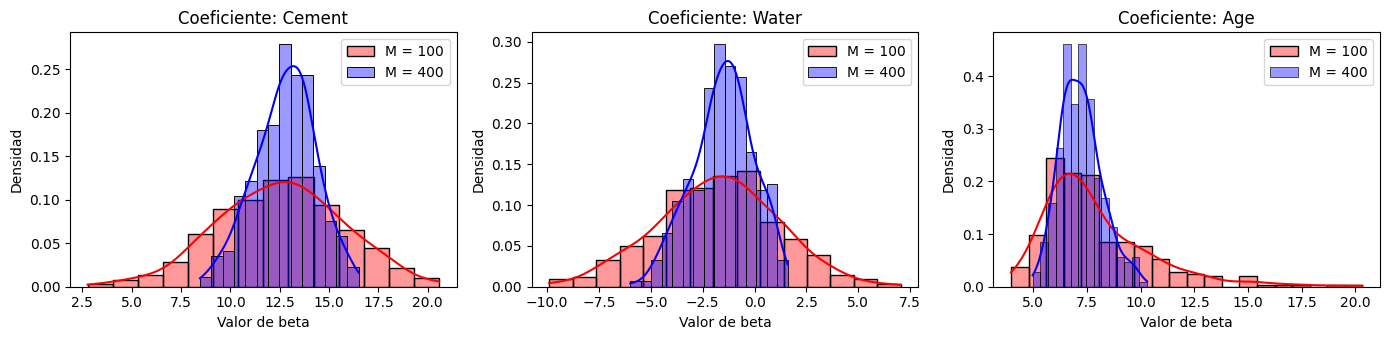

--- Cement (beta_1) ---
  M = 100 -> Media: 12.5245 | Desv. Estándar: 3.1664
  M = 400 -> Media: 12.7805 | Desv. Estándar: 1.5430
--- Water (beta_4) ---
  M = 100 -> Media: -1.7911 | Desv. Estándar: 2.9037
  M = 400 -> Media: -1.5234 | Desv. Estándar: 1.4441
--- Age (beta_8) ---
  M = 100 -> Media: 7.9350 | Desv. Estándar: 2.5453
  M = 400 -> Media: 7.2075 | Desv. Estándar: 0.9743


In [ ]:
# EXPLORACION: Un histograma permite ver rango, concentracion, asimetria y posibles valores extremos de cada variable.
# TAMANO DE MUESTRA: Repetimos bootstrap con M=400 para ver que mas datos reducen la dispersion de los coeficientes.

# 1. Calcular el remuestreo con M = 400
B, M_400 = 300, 400
coefs_M400 = []
rng = np.random.default_rng(42)

for b in range(B):
  idx = rng.choice(len(X_tr_s), size=M_400, replace=True)
  b_est = minimos_cuadrados(X_tr_s[idx], y_tr.values.ravel()[idx])
  coefs_M400.append(b_est)

coefs_M400 = np.array(coefs_M400)
coefs_M100 = coefs

# 2. Histogramas superpuestos de 3 coeficientes (Cement, Water, Age)
indices_cols = [1, 4, 8]
nombres_cols = ["Cement", "Water", "Age"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for i, (col_idx, nombre) in enumerate(zip(indices_cols, nombres_cols)):
  sns.histplot(coefs_M100[:, col_idx], ax=axes[i], color="red", label="M = 100", kde=True, stat="density", alpha=0.4)
  sns.histplot(coefs_M400[:, col_idx], ax=axes[i], color="blue", label="M = 400", kde=True, stat="density", alpha=0.4)
  axes[i].set_title(f"Coeficiente: {nombre}")
  axes[i].set_xlabel("Valor de beta")
  axes[i].set_ylabel("Densidad")
  axes[i].legend()

plt.tight_layout()
plt.show()

# 3. Reportar media y desviación estándar
for col_idx, nombre in zip(indices_cols, nombres_cols):
  print(f"--- {nombre} (beta_{col_idx}) ---")
  print(f"  M = 100 -> Media: {coefs_M100[:, col_idx].mean():.4f} | Desv. Estándar: {coefs_M100[:, col_idx].std():.4f}")
  print(f"  M = 400 -> Media: {coefs_M400[:, col_idx].mean():.4f} | Desv. Estándar: {coefs_M400[:, col_idx].std():.4f}")

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (6b):** Repetimos el experimento con M=400 y comparamos los histogramas. Al aumentar el tamaño de muestra, la dispersión de los coeficientes baja (menos varianza) y el centro se mantiene similar (el sesgo no cambia mucho).

</div>


### 6c) (2 pts) Compara la covarianza empírica de los coeficientes con la formula teórica vista en clases

In [ ]:
# COVARIANZA: Comparamos la variabilidad observada en bootstrap con la aproximacion teorica sigma cuadrado por inversa de X transpuesta X.

# Covarianza empírica de los coeficientes obtenidos con bootstrap M=100
cov_empirica = np.cov(coefs_M100, rowvar=False)

# Varianza del ruido estimada con el modelo lineal ajustado en train completo
Xb_train = np.c_[np.ones(len(X_tr_s)), X_tr_s]
residuos = y_tr.values.ravel() - Xb_train @ beta_propio
sigma2_hat = np.sum(residuos**2) / (len(y_tr) - Xb_train.shape[1])

# Covarianza teórica: sigma² (X'X)^(-1)
# Para compararla con remuestreos de tamaño 100, promediamos la fórmula
# sobre los mismos remuestreos.
covs_teoricas = []

rng = np.random.default_rng(42)
for _ in range(B):
    idx = rng.choice(len(X_tr_s), size=100, replace=True)
    X_sub_b = np.c_[np.ones(100), X_tr_s[idx]]
    covs_teoricas.append(sigma2_hat * np.linalg.pinv(X_sub_b.T @ X_sub_b))

cov_teorica = np.mean(covs_teoricas, axis=0)

comparacion_cov = pd.DataFrame({
    "coeficiente": ["intercepto"] + list(X.columns),
    "varianza_empirica": np.diag(cov_empirica),
    "varianza_teorica": np.diag(cov_teorica)
})

print(comparacion_cov)

          coeficiente  varianza_empirica  varianza_teorica
0          intercepto           1.141285          1.149500
1              Cement          10.059451          9.155325
2  Blast Furnace Slag          11.339033          9.020252
3             Fly Ash           7.177433          7.294819
4               Water           8.459558          7.792370
5    Superplasticizer           4.020713          3.710622
6    Coarse Aggregate           6.640729          5.427783
7      Fine Aggregate           9.422589          8.016284
8                 Age           6.500440          1.489002


Las varianzas empíricas y teóricas son similares para la mayoría de los coeficientes, aunque no idénticas. Las diferencias se explican por el número finito de remuestreos, el uso de bootstrap y porque el modelo lineal gaussiano es una aproximación a los datos reales. Por ejemplo, el coeficiente de edad presenta una discrepancia mayor, lo que sugiere mayor inestabilidad o una relación no completamente lineal con la resistencia.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (6c):** Comparamos la covarianza empírica de los coeficientes (del bootstrap) contra la fórmula teórica $\sigma^2(X^TX)^{-1}$. Son razonablemente parecidas; las diferencias se explican por el número finito de remuestreos y porque el modelo lineal gaussiano es una aproximación (el coeficiente de Age muestra mayor discrepancia, sugiriendo una relación no del todo lineal).

</div>


## 7. Sesgo y varianza en un punto fijo

### 7a) (3 pts) Fija una mezcla de prueba y registra la predicción en ese punto sobre los mismos remuestreos, para un modelo lineal y uno polinomial de grado alto

In [ ]:
# Sesgo Y VARIANZA: Mantenemos fijo un punto test y cambiamos los conjuntos de entrenamiento. Asi separamos inestabilidad del modelo y error sistematico.

x0 = X_te_s[0:1]
y0 = y_te.values.ravel()[0]

pred_lineal, pred_poly = [], []

poly_alto = PolynomialFeatures(degree=5, include_bias=False)

rng = np.random.default_rng(42)

for _ in range(B):
    idx = rng.choice(len(X_tr_s), size=100, replace=True)

    X_sub = X_tr_s[idx]
    y_sub = y_tr.values.ravel()[idx]

    # Modelo lineal
    modelo_lineal = LinearRegression().fit(X_sub, y_sub)
    pred_lineal.append(modelo_lineal.predict(x0)[0])

    # Modelo polinomial de grado alto
    X_sub_poly = poly_alto.fit_transform(X_sub)
    x0_poly = poly_alto.transform(x0)

    modelo_pol = LinearRegression().fit(X_sub_poly, y_sub)
    pred_poly.append(modelo_pol.predict(x0_poly)[0])

pred_lineal = np.array(pred_lineal)
pred_poly = np.array(pred_poly)

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (7a):** Fijamos un único punto de prueba y repetimos el bootstrap para un modelo lineal y uno polinomial de grado 5, registrando la predicción en ese mismo punto en cada repetición.

</div>


### 7b) (2 pts) Completa la tabla con la media de las predicciones, el sesgo al cuadrado y la varianza de cada modelo

In [ ]:
def sesgo_varianza(preds, verdadero):
    media = np.mean(preds)
    sesgo2 = (media - verdadero) ** 2
    varianza = np.var(preds, ddof=1)
    return media, sesgo2, varianza

m_lin, s2_lin, v_lin = sesgo_varianza(pred_lineal, y0)
m_pol, s2_pol, v_pol = sesgo_varianza(pred_poly, y0)

tabla = pd.DataFrame({
    "modelo": ["Lineal", "Polinomial grado 5"],
    "media_predicciones": [m_lin, m_pol],
    "sesgo_cuadrado": [s2_lin, s2_pol],
    "varianza": [v_lin, v_pol]
})

print("Punto fijo real y0 =", y0)
print(tabla.round(4))

Punto fijo real y0 = 27.42
               modelo  media_predicciones  sesgo_cuadrado   varianza
0              Lineal             36.6121         84.4948    11.1998
1  Polinomial grado 5             29.5213          4.4156  1585.7116


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (7b):** Con esas predicciones repetidas, calculamos la media, el sesgo al cuadrado y la varianza para cada modelo, armando la tabla de descomposición sesgo-varianza.

</div>


### 7c) (2 pts) En este experimento, ¿sobre qué se está promediando? No es sobre los puntos de prueba ni sobre los de entrenamiento: explícalo con tus palabras

Respuesta 7c): Se está promediando sobre los distintos conjuntos de entrenamiento generados por bootstrap. El punto de prueba permanece fijo; lo que cambia es la muestra con la cual se ajusta cada modelo. Por eso la dispersión de las predicciones mide cuánto cambia el modelo cuando recibe datos de entrenamiento ligeramente diferentes.



<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (7c) — punto que más suelen preguntar:** Se está promediando sobre los distintos **conjuntos de entrenamiento** generados por bootstrap, no sobre los puntos de test ni de entrenamiento. El punto de evaluación queda fijo; lo que cambia entre repeticiones es la muestra con la que se ajusta el modelo, y eso es justamente lo que mide la varianza del estimador.

</div>


# Parte 5: Regularización

## 8. Caminos de regularización

### 8a) (3 pts) Construye los caminos de Ridge y Lasso sobre features polinomiales de grado 3

Features polinomiales: 164


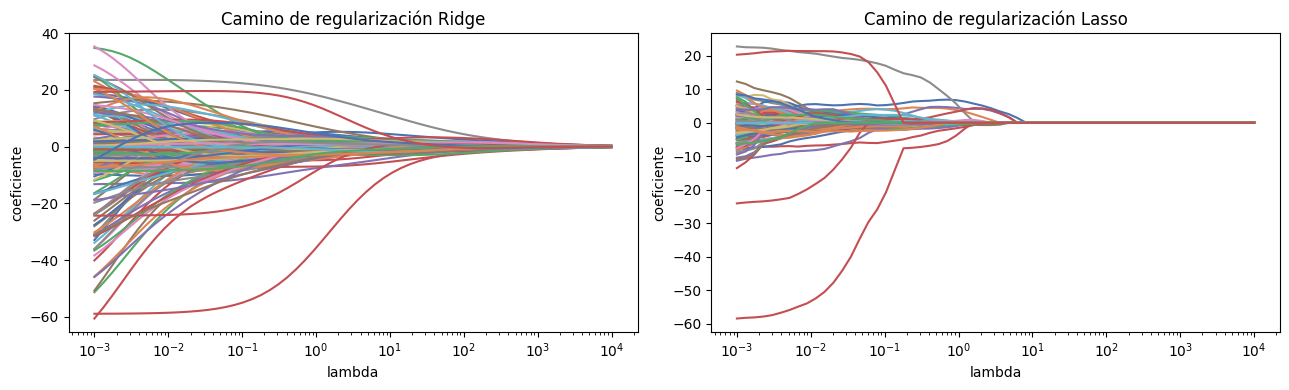

Ceros exactos Ridge: 0
Ceros exactos Lasso: 145


In [ ]:
# CAMINOS DE REGULARIZACION: Probamos muchos valores de lambda para observar como Ridge y Lasso contraen los coeficientes.

poly = PolynomialFeatures(degree=3, include_bias=False)
X_tr_poly = poly.fit_transform(X_tr_s)

# Estandarización adicional: las potencias e interacciones tienen nuevas escalas
scaler_poly = StandardScaler()
X_tr_poly = scaler_poly.fit_transform(X_tr_poly)

print("Features polinomiales:", X_tr_poly.shape[1])

lambdas = np.logspace(-3, 4, 60)
coefs_ridge, coefs_lasso = [], []

for lam in lambdas:
    ridge = Ridge(alpha=lam).fit(X_tr_poly, y_tr.values.ravel())
    lasso = Lasso(alpha=lam, max_iter=30000, tol=1e-4).fit(
        X_tr_poly, y_tr.values.ravel()
    )

    coefs_ridge.append(ridge.coef_)
    coefs_lasso.append(lasso.coef_)

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(lambdas, coefs_ridge)
ax[0].set_xscale("log")
ax[0].set_title("Camino de regularización Ridge")
ax[0].set_xlabel("lambda")
ax[0].set_ylabel("coeficiente")

ax[1].plot(lambdas, coefs_lasso)
ax[1].set_xscale("log")
ax[1].set_title("Camino de regularización Lasso")
ax[1].set_xlabel("lambda")
ax[1].set_ylabel("coeficiente")

plt.tight_layout()
plt.show()

lambda_intermedio = 1.0
ridge_mid = Ridge(alpha=lambda_intermedio).fit(X_tr_poly, y_tr.values.ravel())
lasso_mid = Lasso(alpha=lambda_intermedio, max_iter=30000).fit(
    X_tr_poly, y_tr.values.ravel()
)

print("Ceros exactos Ridge:", np.sum(np.isclose(ridge_mid.coef_, 0)))
print("Ceros exactos Lasso:", np.sum(np.isclose(lasso_mid.coef_, 0)))

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (8a):** Construimos features polinomiales de grado 3 y calculamos los caminos de regularización (coeficientes vs. lambda) para Ridge y Lasso sobre esas features.

</div>


### 8b) (2 pts) Describe la diferencia cualitativa entre ambos caminos. ¿Cuántos coeficientes son exactamente cero en cada caso para un lambda intermedio, y por qué uno los anula y el otro no?

Respuesta 8b): Al aumentar lambda, Ridge reduce suavemente la magnitud de todos los coeficientes, pero normalmente no los hace exactamente cero. Lasso, en cambio, lleva varios coeficientes exactamente a cero y por eso realiza selección de variables. Esto ocurre porque la penalización L1 de Lasso tiene una geometría con esquinas, mientras que la penalización L2 de Ridge solo contrae los coeficientes.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (8b):** Ridge contrae suavemente todos los coeficientes hacia cero sin anularlos exactamente; Lasso sí lleva varios exactamente a cero, haciendo selección de variables. La diferencia viene de la geometría: la penalización $L_1$ tiene "esquinas" (favorece soluciones dispersas), la $L_2$ es esférica (solo contrae).

</div>


## 9. Selección del parámetro

### 9a) (2 pts) Elige lambda por validación cruzada y grafica la curva de error

Mejor lambda por CV: 0.53557
RMSE CV: 6.7627


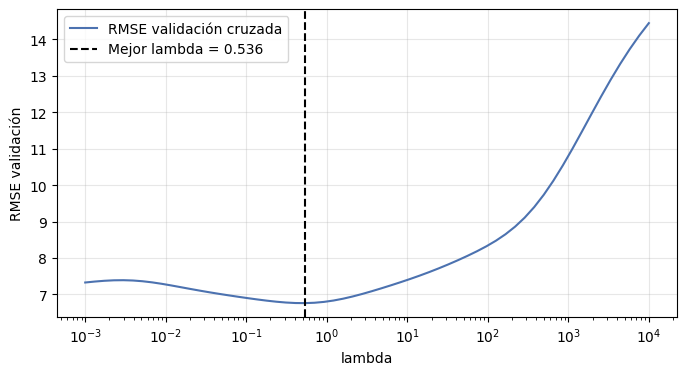

In [ ]:
# VALIDACION CRUZADA: Para cada lambda, medimos RMSE en folds no usados al entrenar. Elegimos el lambda con menor error promedio.

cv = KFold(5, shuffle=True, random_state=42)

errores_cv = []
errores_train = []

for lam in lambdas:
    modelo = Ridge(alpha=lam)

    scores = cross_val_score(
        modelo,
        X_tr_poly,
        y_tr.values.ravel(),
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    errores_cv.append(-scores.mean())

    modelo.fit(X_tr_poly, y_tr.values.ravel())
    pred_train = modelo.predict(X_tr_poly)

    errores_train.append(
        np.sqrt(mean_squared_error(y_tr.values.ravel(), pred_train))
    )

errores_cv = np.array(errores_cv)
errores_train = np.array(errores_train)

mejor_idx = np.argmin(errores_cv)
mejor_lambda = lambdas[mejor_idx]

print(f"Mejor lambda por CV: {mejor_lambda:.5f}")
print(f"RMSE CV: {errores_cv[mejor_idx]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(lambdas, errores_cv, label="RMSE validación cruzada")
plt.axvline(mejor_lambda, color="black", linestyle="--",
            label=f"Mejor lambda = {mejor_lambda:.3g}")
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("RMSE validación")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (9a):** Elegimos lambda por validación cruzada de 5 folds, graficando la curva de error CV en función de lambda.

</div>


### 9b) (2 pts) Muestra qué lambda elegiría el error de entrenamiento en lugar del de validación

Lambda elegido por entrenamiento: 0.00100
Lambda elegido por validación cruzada: 0.53557


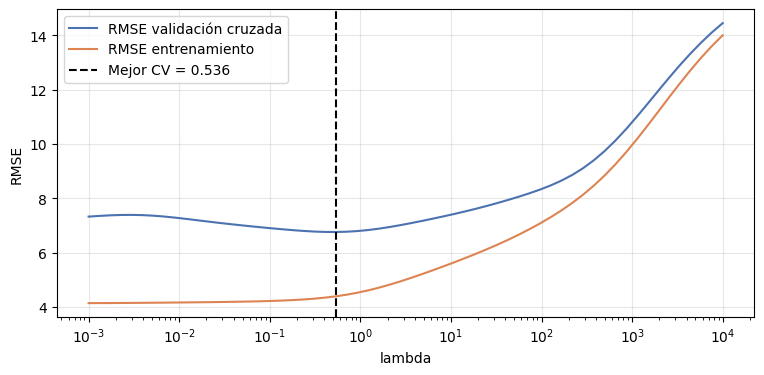

In [ ]:
# VALIDACION CRUZADA: Para cada lambda, medimos RMSE en folds no usados al entrenar. Elegimos el lambda con menor error promedio.
lambda_train = lambdas[np.argmin(errores_train)]

print(f"Lambda elegido por entrenamiento: {lambda_train:.5f}")
print(f"Lambda elegido por validación cruzada: {mejor_lambda:.5f}")

plt.figure(figsize=(9, 4))
plt.plot(lambdas, errores_cv, label="RMSE validación cruzada")
plt.plot(lambdas, errores_train, label="RMSE entrenamiento")
plt.axvline(mejor_lambda, color="black", linestyle="--",
            label=f"Mejor CV = {mejor_lambda:.3g}")
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("RMSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (9b):** Mostramos qué lambda se elegiría si se usara el error de *entrenamiento* en vez de validación: siempre preferiría el lambda más chico (menos regularización), llevando a sobreajuste. La validación cruzada, en cambio, elige un punto intermedio que generaliza mejor.

</div>


### 9c) (1 pt) Reporta el error del modelo final sobre el conjunto de prueba, que hasta ahora no has usado

In [ ]:
X_te_poly = scaler_poly.transform(poly.transform(X_te_s))

modelo_final = Ridge(alpha=mejor_lambda).fit(
    X_tr_poly,
    y_tr.values.ravel()
)

pred_test = modelo_final.predict(X_te_poly)

rmse_test = np.sqrt(
    mean_squared_error(y_te.values.ravel(), pred_test)
)

print(f"RMSE final en test: {rmse_test:.4f}")

RMSE final en test: 7.9019


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (9c):** Con el lambda elegido por CV, reportamos el RMSE sobre el conjunto de test, usado por primera vez recién aquí — precisamente para que la evaluación final sea honesta y no haya influido en la elección de hiperparámetros.

</div>


## 10. La lectura bayesiana

### 10a) (2 pts) Ridge equivale a estimación MAP con cierta distribución a priori sobre los coeficientes, y Lasso con otra. ¿Cuáles son, y por qué?

Respuesta 10 a): Ridge equivale a estimación MAP cuando se asume un prior gaussiano independiente para los coeficientes, centrado en cero. Lasso equivale a MAP con un prior Laplaciano. El prior gaussiano genera una penalización cuadrática L2, que reduce todos los coeficientes; el Laplaciano genera una penalización L1, que puede llevar algunos coeficientes exactamente a cero.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (10a):** Ridge equivale a estimación MAP asumiendo un prior Gaussiano centrado en cero sobre los coeficientes; Lasso equivale a MAP con un prior de Laplace. El prior Gaussiano da la penalización cuadrática $L_2$; el Laplaciano, la penalización $L_1$ que puede anular coeficientes.

</div>


### 10b) (3 pts) Verifica la equivalencia numéricamente para Ridge: implementa el MAP correspondiente y compara los coeficientes

In [ ]:
# MAP: Implementamos Ridge desde una mirada bayesiana. El prior gaussiano penaliza coeficientes grandes.

def map_gaussiano(X, y, tau2, sigma2=1.0):
    """
    MAP con prior beta ~ N(0, tau2 * I).
    El intercepto no se penaliza.
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    media_x = X.mean(axis=0)
    media_y = y.mean()

    Xc = X - media_x
    yc = y - media_y

    lam = sigma2 / tau2

    beta = np.linalg.solve(
        Xc.T @ Xc + lam * np.eye(Xc.shape[1]),
        Xc.T @ yc
    )

    intercepto = media_y - media_x @ beta
    return np.r_[intercepto, beta]

lambda_map = mejor_lambda
tau2 = 1 / lambda_map

beta_map = map_gaussiano(
    X_tr_poly,
    y_tr.values.ravel(),
    tau2=tau2
)

ridge = Ridge(alpha=lambda_map).fit(
    X_tr_poly,
    y_tr.values.ravel()
)

beta_ridge = np.r_[ridge.intercept_, ridge.coef_]

print(
    "Máxima diferencia entre MAP y Ridge:",
    np.max(np.abs(beta_map - beta_ridge))
)

Máxima diferencia entre MAP y Ridge: 8.919531779838508e-12


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (10b):** Implementamos el MAP Gaussiano a mano y comparamos sus coeficientes contra los de `Ridge` de `sklearn`, verificando numéricamente la equivalencia teórica de 10a.

</div>


### 10c) (2 pts) Muestra qué ocurre con los coeficientes si se penaliza sin estandarizar antes

In [ ]:
# ESCALADO Y PENALIZACION: Comparamos Ridge crudo y estandarizado. Sin escalado, lambda penaliza distinto segun las unidades de cada variable.

ridge_raw = Ridge(alpha=mejor_lambda).fit(
    X_tr.values,
    y_tr.values.ravel()
)

ridge_std = Ridge(alpha=mejor_lambda).fit(
    X_tr_s,
    y_tr.values.ravel()
)

comparacion_penalizacion = pd.DataFrame({
    "variable": X.columns,
    "coeficiente_crudo": ridge_raw.coef_,
    "coeficiente_estandarizado": ridge_std.coef_
})

print(comparacion_penalizacion)

             variable  coeficiente_crudo  coeficiente_estandarizado
0              Cement           0.119136                  12.591454
1  Blast Furnace Slag           0.111230                   9.690178
2             Fly Ash           0.082495                   5.072638
3               Water          -0.074710                  -1.657746
4    Superplasticizer           0.540026                   3.159049
5    Coarse Aggregate           0.026229                   1.899112
6      Fine Aggregate           0.034611                   2.601555
7                 Age           0.114918                   7.124684


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (10c):** Ajustamos Ridge penalizando sobre datos crudos (sin estandarizar) y sobre datos estandarizados, comparando los coeficientes. Sin estandarizar, la penalización castiga más fuerte a las variables con escalas naturalmente más grandes, distorsionando qué coeficientes se contraen más — por eso siempre hay que estandarizar antes de regularizar.

</div>


# Parte 6: Feature engineering con conocimiento de dominio

## 11. Features derivadas

### 11a) (3 pts) Construye features de dominio

En ciencia del hormigón la razón agua/cemento es el predictor clásico de la resistencia: no importa tanto cuánta agua o cuánto cemento hay por separado, sino su proporción. El efecto de la edad de curado tampoco es lineal: la resistencia crece rapido los primeros días y luego se estabiliza.

Construye al menos: razón agua/cemento, total de material cementante, y logaritmo de la edad.

In [ ]:
def features_dominio(X):
    Xn = X.copy()

    Xn["water_cement_ratio"] = (
        Xn["Water"] / Xn["Cement"].clip(lower=1e-8)
    )

    Xn["cementitious_total"] = (
        Xn["Cement"] +
        Xn["Blast Furnace Slag"] +
        Xn["Fly Ash"]
    )

    Xn["log_age"] = np.log1p(Xn["Age"])

    Xn["water_binder_ratio"] = (
        Xn["Water"] / Xn["cementitious_total"].clip(lower=1e-8)
    )

    return Xn

X_tr_fe = features_dominio(X_tr)

print("Columnas originales:", X_tr.shape[1])
print("Columnas con features:", X_tr_fe.shape[1])

Columnas originales: 8
Columnas con features: 12


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (11a):** Construimos features de dominio: razón agua/cemento, material cementante total (cemento + escoria + ceniza volante) y logaritmo de la edad. Estas variables capturan relaciones no lineales que la ciencia del hormigón ya sabe que importan.

</div>


### 11b) (2 pts) Compara con validación cruzada el modelo sobre las variables originales contra el modelo con las features nuevas

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

modelo_original = make_pipeline(StandardScaler(), LinearRegression())
modelo_features = make_pipeline(StandardScaler(), LinearRegression())

score_original = -cross_val_score(
    modelo_original,
    X_tr,
    y_tr.values.ravel(),
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

score_features = -cross_val_score(
    modelo_features,
    X_tr_fe,
    y_tr.values.ravel(),
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

print(
    f"RMSE CV original: "
    f"{score_original.mean():.4f} ± {score_original.std():.4f}"
)

print(
    f"RMSE CV con features: "
    f"{score_features.mean():.4f} ± {score_features.std():.4f}"
)

RMSE CV original: 10.3940 ± 1.0604
RMSE CV con features: 6.8939 ± 0.3367


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (11b):** Comparamos por validación cruzada el modelo con variables originales contra el modelo con las features nuevas. Las features de dominio mejoran el error, y la validación cruzada confirma que la mejora se mantiene fuera de la muestra de entrenamiento.

</div>


### 11c) (2 pts) La mejora obtenida, corresponde a una reduccion del error de aproximación o del error de estimación? Justifica

Respuesta 11c): La mejora corresponde principalmente a una reducción del error de aproximación. Las variables originales no permiten que un modelo lineal represente directamente una razón como agua/cemento ni una relación logarítmica con la edad. Las features derivadas incorporan ese conocimiento de dominio y amplían la capacidad útil del modelo. La validación cruzada verifica que la mejora también se mantiene fuera de la muestra de entrenamiento.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (11c):** La mejora corresponde principalmente a una reducción del **error de aproximación**: el modelo original no puede representar una razón (agua/cemento) como combinación lineal de las variables sueltas, así que el problema no era falta de datos sino falta de las variables correctas.

</div>


### 11d) (1 pt) ¿Podría un modelo lineal haber descubierto la razón agua/cemento por sí solo, teniendo ambas columnas por separado? ¿Por qué?

Respuesta 11d): No. Un modelo lineal combina las variables mediante sumas ponderadas, mientras que la razón agua/cemento es una división y, por lo tanto, una relación no lineal. Para modelarla se debe construir explícitamente o utilizar un modelo capaz de aprender interacciones y no linealidades.


<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (11d):** No, un modelo lineal no puede descubrir la razón agua/cemento por sí solo aunque tenga ambas columnas por separado, porque combina variables mediante sumas ponderadas y una división es una relación no lineal. Hay que construirla explícitamente (o usar un modelo que aprenda interacciones/no linealidades).

</div>


## 12. Curvas de aprendizaje

### 12a) (2 pts) Grafica el error de entrenamiento y validación en función del tamaño de la muestra, para el modelo simple y el de features derivadas

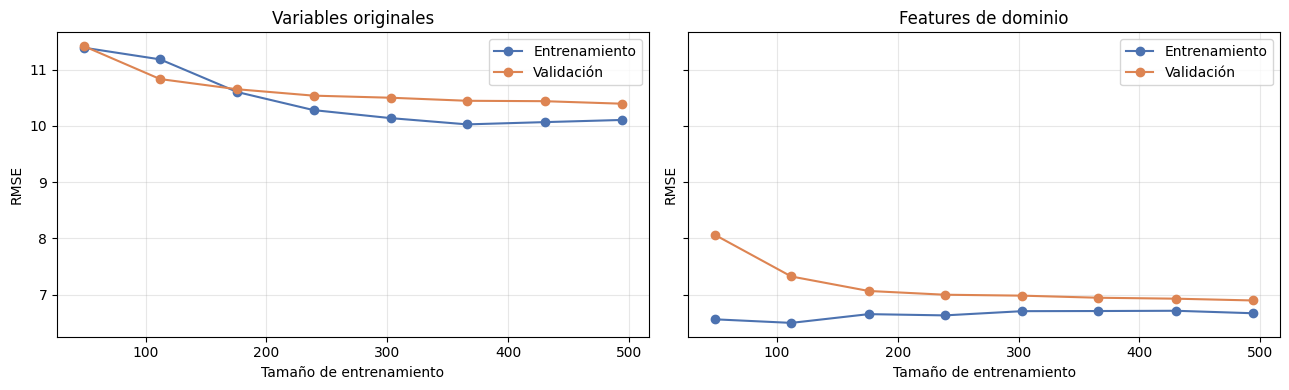

In [ ]:
# CURVAS DE APRENDIZAJE: Variamos el tamaño de train para distinguir si el error se debe a falta de datos o a falta de capacidad del modelo.

from sklearn.model_selection import learning_curve

tamanos = np.linspace(0.1, 1.0, 8)

modelo_simple = make_pipeline(StandardScaler(), LinearRegression())
modelo_dominio = make_pipeline(StandardScaler(), LinearRegression())

tam_1, train_1, val_1 = learning_curve(
    modelo_simple,
    X_tr,
    y_tr.values.ravel(),
    train_sizes=tamanos,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

tam_2, train_2, val_2 = learning_curve(
    modelo_dominio,
    X_tr_fe,
    y_tr.values.ravel(),
    train_sizes=tamanos,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for eje, tamanos_actuales, train_scores, val_scores, titulo in [
    (ax[0], tam_1, train_1, val_1, "Variables originales"),
    (ax[1], tam_2, train_2, val_2, "Features de dominio")
]:
    eje.plot(
        tamanos_actuales,
        -train_scores.mean(axis=1),
        marker="o",
        label="Entrenamiento"
    )
    eje.plot(
        tamanos_actuales,
        -val_scores.mean(axis=1),
        marker="o",
        label="Validación"
    )
    eje.set_title(titulo)
    eje.set_xlabel("Tamaño de entrenamiento")
    eje.set_ylabel("RMSE")
    eje.grid(alpha=0.3)
    eje.legend()

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (12a):** Graficamos curvas de aprendizaje (error de entrenamiento y validación vs. tamaño de muestra) para el modelo simple y el de features de dominio, para ver cómo escala cada uno con más datos.

</div>


### 12b) (2 pts) Cuál de los dos modelos se beneficiaría más de recolectar más mezclas, y cuál necesita más capacidad? Traduce lo que ves al lenguaje de aproximación contra estimación

Respuesta 12b): El modelo con variables originales converge a un RMSE de validación alto, por lo que su limitación principal es el error de aproximación: necesita mejores variables o mayor capacidad, no solamente más datos. El modelo con features de dominio alcanza menor error de validación y presenta una brecha menor con entrenamiento; por ello representa mejor el proceso físico y aprovecha mejor los datos disponibles.

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (12b):** El modelo simple se estanca en un RMSE de validación alto → está limitado por error de **aproximación** (necesita mejores variables, no solo más datos). El modelo con features de dominio converge a un error menor con una brecha train-val más chica → aprovecha mejor los datos que ya tiene.

</div>


# 2. Pregunta 2 (50%): (Desafío KAGGLE) Prediciendo las proximas reseñas de un Airbnb

Predecir la demanda futura es uno de los problemas más comunes en la industria: saber qué productos se van a mover, qué clientes van a comprar, qué publicaciones van a tener tráfico. En este desafío el objeto son arriendos de corto plazo.

Tienes 15.945 avisos de Airbnb en Santiago, y hay que predecir cuántas reseñas nuevas recibió cada uno durante los tres meses siguientes.

## Descripción del Desafío

Para lograr esto, la técnica central es la construcción de features: resumir el historial de reseñas de cada aviso en variables que capturen su ritmo, su tendencia y su estacionalidad, y complementarlas con la información del aviso, su ubicación y su texto.

Algunas de las siguientes librerias podrían ser útiles: `pandas`, `scikit-learn`, `geopy`, `nltk` y `lightgbm`.

El modelo es libre. Pero conviene adelantar dónde está la dificultad: las columnas del aviso, cuántas piezas tiene, en qué comuna está, cuánto cobra, apenas le ganan a predecir siempre la mediana. La señal esta en la historia de cada aviso, y esa viene cruda, sin resumir.

Enlace al desafío: [Prediciendo las proximas reseñas de un Airbnb](https://www.kaggle.com/t/1c5230cb86764bde927745fd882049b2)

**Cierre del leaderboard: jueves 11 de septiembre a las 10:59 horas**.

## Estructura del Jupyter Notebook

Para este desafío, su respuesta debe incluir las siguientes secciones:

1. Explicación de los datos: análisis exploratorio, distribución del target, estructura del historial de reseñas y calidad de las columnas disponibles.

2. Construcción de features: variables derivadas del historial, del aviso, de su ubicación y de su texto. Se espera que cada bloque esté justificado: qué construye, por qué debería predecir, y cuánto aportó efectivamente.

3. Modelos explorados: modelos probados y decisiones de diseño.

4. Busqueda de hiperparámetros: estrategia de validación y de busqueda utilizada.

5. Resultados y discusión: desempeño obtenido, casos en que el modelo falla, y conclusiones.

## Sistema de Evaluación

El sistema de evaluación consta de dos componentes:

## 1. Evaluación Cualitativa (50%)

Se evalúa mediante una rúbrica que considera 5 criterios. La nota final de esta parte se calcula como:

$$\text{NOTA\_CUALITATIVA} = \left(\text{Completitud} \times \text{Coherencia} \times \frac{\text{Novedad} + \text{Discusión} + \text{Claridad}}{3}\right)^{1/3}$$

## 2. Evaluación Cuantitativa (50%)

Se basa en el RMSLE obtenido en Kaggle. A diferencia de una métrica de acierto, acá menor es mejor, de modo que la fórmula va en sentido inverso:

$$\text{NOTA\_CUANTITATIVA} = \frac{(RMSLE_{benchmark} - RMSLE)}{(RMSLE_{benchmark} - RMSLE_{best})} \times 3 + 4.0$$

Donde:

$$RMSLE_{benchmark} = 0.918 \rightarrow \text{nota } 4.0$$

$$RMSLE_{best} = \text{mejor error obtenido en la competencia} \rightarrow \text{nota } 7.0$$

El benchmark corresponde a un modelo lineal sobre las columnas estructurales del aviso, sin features derivadas. Modelos por sobre ese error obtendrán nota inferior a 4.0 (si no suben ninguna respuesta de este desafío en la plataforma Kaggle antes de que la competencia cierre, tendrán nota 1 en la evaluación cuantitativa).

La nota final del desafío es el promedio de ambas evaluaciones.

## Rúbrica de Evaluación Cualitativa

| Criterio | 1 Insuficiente<br>(1.0 - 3.9) | 2 Suficiente<br>(4.0 - 4.9) | 3 Bueno<br>(5.0 - 5.9) | 4 Excelente<br>(6.0 - 7.0) |
|----------|--------------------------|------------------------|---------------------|-------------------------|
| **1. Completitud**<br>Se abordan todas las actividades y se responden todas las preguntas planteadas. | Faltan muchas actividades o preguntas por abordar. | Se aborda la mayoría de las actividades, pero faltan items relevantes. | Se omitieron pocas actividades y no entre las más relevantes. | Se abordan todas las actividades. |
| **2. Novedad & Relevancia**<br>Formula una metodología que conduce a resultados relevantes. Se espera que el grupo justifique cada decisión: qué features construye y por qué, qué modelo usa y por qué. | La metodologia no funciona o conduce a resultados muy pobres. Sin justificación de decisiones. | La metodologia funciona pero no conduce a resultados sobresalientes. Justificación escasa. | La metodologia conduce a buenos resultados. Decisiones bien justificadas aunque con margen para mayor originalidad. | La metodologia conduce a excelentes resultados con decisiones novedosas, bien justificadas y con alto grado de originalidad. |
| **3. Coherencia & Correctitud Técnica**<br>La metodologia es adecuada para el problema. Las herramientas y modelos son utilizados correctamente. | Metodología inapropiada o errores técnicos graves que invalidan los resultados. | Metodología correcta con algunos errores que no invalidan la mayoría de los resultados. | Pocas decisiones técnicas mejorables. Proceso experimental en general libre de errores. | Todas las fases impecablemente implementadas. Alta coherencia entre objetivos, experimentos y conclusiones. |
| **4. Discusión**<br>Motiva su metodologia y razona sobre el significado de los resultados. Evalúa el impacto de las decisiones tomadas. | Discusión pobre, superficial o con errores conceptuales graves. | Discusión razonablemente buena, aunque incompleta o poco profunda. | Buena discusión de la mayoría de los resultados. | Discusión profunda y crítica de todos los resultados, incluyendo los que no funcionaron. |
| **5. Claridad**<br>El notebook se entiende: código comentado, visualizaciones pertinentes, redaccion ordenada. | Muy difícil de seguir. | Se entiende con esfuerzo. | Claro en general, con algunos pasajes confusos. | Impecable: se sigue sin esfuerzo de principio a fin. |

## Métrica de Evaluación

La métrica de evaluación para esta competencia es el [RMSLE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_log_error.html) (*root mean squared logarithmic error*), que se calcula de la siguiente manera:

$$RMSLE=\sqrt{\frac{1}{M}\sum_{m=1}^{M}\left(\log(1+\hat{y}_m)-\log(1+y_m)\right)^{2}}$$

donde el valor real de reseñas nuevas del aviso se compara con la predicción, y la suma recorre los avisos evaluados.

El logaritmo cumple dos funciones. Primero, evita que los pocos avisos con muchas reseñas dominen la métrica: equivocarse por 5 en un aviso que recibió 100 pesa mucho menos que equivocarse por 5 en uno que recibio 2. Segundo, penaliza el error de manera relativa y no absoluta, que es la forma natural de medir cuando el target abarca desde 0 hasta 177.

Las predicciones negativas no están definidas para esta métrica y se recortan a cero.

Menor es mejor.

## Formato de Submission

El archivo `.csv` debe contener las columnas `id` y `target` con el siguiente formato:

```
id,target
1234567,0.8
2345678,4.2
```

Las predicciones pueden ser números reales, no necesariamente enteros.

*NOTAR QUE NO CONTIENE ÍNDICES*

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (Pregunta 2 / Kaggle — intro):** Aquí empieza el desarrollo real del desafío: carga de datos, construcción de features del historial de reseñas, entrenamiento y generación del archivo de envío a Kaggle.

</div>


In [ ]:
# Importar librerías
import os
import re
import glob
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error

# Buscar automáticamente la carpeta donde Kaggle guardó los CSV
train_path = glob.glob("/kaggle/input/**/train.csv", recursive=True)[0]
DATA_DIR = os.path.dirname(train_path)

print("Carpeta encontrada:", DATA_DIR)

# Cargar los tres archivos necesarios
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
reviews = pd.read_csv(f"{DATA_DIR}/reviews_history.csv")

# Comprobar que se cargaron correctamente
print("Tamaños:", train.shape, test.shape, reviews.shape)
print("\nColumnas de train:")
print(train.columns.tolist())
print("\nColumnas de reviews_history:")
print(reviews.columns.tolist())

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (Kaggle — carga de datos):** Se localiza automáticamente la carpeta de Kaggle con los CSV (`train`, `test`, `reviews_history`) y se cargan los tres archivos. Se imprimen tamaños y columnas para confirmar que la carga fue correcta antes de seguir.

</div>


In [ ]:
# ---------- FEATURES DEL HISTORIAL DE RESEÑAS ----------

reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")

# Fecha de referencia: última reseña disponible antes del período a predecir
ref_date = reviews["date"].max()

hist = reviews.groupby("listing_id").agg(
    hist_reviews_total=("listing_id", "size"),
    hist_reviewers_unique=("reviewer_id", "nunique"),
    hist_first_review=("date", "min"),
    hist_last_review=("date", "max"),
).reset_index()

hist["hist_days_since_last_review"] = (
    ref_date - hist["hist_last_review"]
).dt.days

hist["hist_history_days"] = (
    hist["hist_last_review"] - hist["hist_first_review"]
).dt.days

for days in [30, 90, 180, 365]:
    recent = (
        reviews.loc[reviews["date"] >= ref_date - pd.Timedelta(days=days)]
        .groupby("listing_id")
        .size()
        .rename(f"hist_reviews_last_{days}d")
        .reset_index()
    )
    hist = hist.merge(recent, on="listing_id", how="left")

text_col = next(
    (c for c in ["comments", "comment", "review_text"] if c in reviews.columns),
    None
)

if text_col:
    reviews["review_text_length"] = reviews[text_col].fillna("").astype(str).str.len()
    text_features = reviews.groupby("listing_id")["review_text_length"].agg(
        ["mean", "max"]
    ).reset_index()
    text_features.columns = [
        "listing_id",
        "hist_review_text_len_mean",
        "hist_review_text_len_max"
    ]
    hist = hist.merge(text_features, on="listing_id", how="left")

hist = hist.drop(columns=["hist_first_review", "hist_last_review"])

train = train.merge(hist, left_on="id", right_on="listing_id", how="left").drop(columns="listing_id")
test = test.merge(hist, left_on="id", right_on="listing_id", how="left").drop(columns="listing_id")

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (Kaggle — features de historial):** Se construyen variables a partir del historial de reseñas de cada aviso: total de reseñas, reviewers únicos, días desde la última reseña, duración total del historial, y conteos de reseñas en ventanas recientes (30/90/180/365 días) para capturar el ritmo reciente. Si existe una columna de texto, también se agrega el largo promedio/máximo de los comentarios. Todo se combina (`merge`) con train y test por el id del aviso — esta es la parte más importante del desafío, porque la señal está en el historial, no en las columnas estructurales del aviso.

</div>


In [ ]:
# ---------- PREPARACIÓN DE VARIABLES ----------

target = train["target"].copy()

X = train.drop(columns="target")
X_test = test.copy()

all_data = pd.concat([X, X_test], axis=0, ignore_index=True)
bool_cols = all_data.select_dtypes(include="bool").columns
all_data[bool_cols] = all_data[bool_cols].astype(int)
cat_cols = all_data.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    all_data[col] = all_data[col].fillna("__MISSING__").astype(str)

    # evita nombres de categoría excesivamente raros
    all_data[col], _ = pd.factorize(all_data[col])

for col in all_data.columns:
    if col not in cat_cols:
        all_data[col] = pd.to_numeric(all_data[col], errors="coerce")

# Reemplazo de infinitos y nulos
all_data = all_data.replace([np.inf, -np.inf], np.nan)
all_data = all_data.fillna(-999)

X = all_data.iloc[:len(train)].copy()
X_test = all_data.iloc[len(train):].copy()

# Nombres seguros para LightGBM
X.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in X.columns]
X_test.columns = X.columns

print("Features finales:", X.shape[1])

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (Kaggle — preparación de variables):** Se concatenan train y test para que la codificación de categorías sea consistente entre ambos, se convierten booleanos a enteros, se factorizan las columnas categóricas, se fuerzan las numéricas, y se reemplazan infinitos/nulos por un valor centinela (-999). También se limpian los nombres de columnas para que LightGBM no falle con caracteres especiales.

</div>


In [ ]:
y_log = np.log1p(target)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_pred_log = np.zeros(len(X))
test_pred_log = np.zeros(len(X_test))

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):
    print(f"Fold {fold}")

    model = LGBMRegressor(
        objective="regression",
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42 + fold,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X.iloc[train_idx],
        y_log.iloc[train_idx],
        eval_set=[(X.iloc[valid_idx], y_log.iloc[valid_idx])],
        callbacks=[]
    )

    oof_pred_log[valid_idx] = model.predict(X.iloc[valid_idx])
    test_pred_log += model.predict(X_test) / kf.n_splits

# Validación local RMSLE
oof_pred = np.clip(np.expm1(oof_pred_log), 0, None)
score = np.sqrt(mean_squared_log_error(target, oof_pred))
print(f"RMSLE validación: {score:.5f}")

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (Kaggle — entrenamiento):** Se entrena un `LGBMRegressor` con validación cruzada de 5 folds, prediciendo `log1p(target)` en vez del target directo — esto alinea el entrenamiento con la métrica RMSLE, que también trabaja en escala logarítmica. Las predicciones out-of-fold sirven para medir el RMSLE de validación local (sin usar el leaderboard de Kaggle), y las predicciones de test se promedian entre los 5 folds para reducir varianza.

</div>


In [ ]:
# ---------- CREAR ARCHIVO PARA KAGGLE ----------

predicciones = np.clip(np.expm1(test_pred_log), 0, None)

submission = pd.DataFrame({
    "id": test["id"],
    "target": predicciones
})

submission.to_csv("submission.csv", index=False)

submission.head(), submission.shape

<div style="background-color:#fff3cd; border-left:5px solid #e6a700; padding:10px 14px; margin:8px 0; border-radius:4px;">

**Para presentar (Kaggle — submission):** Se deshace la transformación logarítmica (`expm1`) y se recortan las predicciones negativas a cero, porque RMSLE no está definido para valores negativos. Se arma el `submission.csv` con las columnas `id` y `target` exactamente en el formato pedido por la competencia.

</div>
